# 作业二：推导RNN情况下的反向传播；推导并计算语言模型PPL

姓名：韩岳成

学号：524531910029

## 作业目标
在本次作业中，你将使用一个经典的transformer模型，并且实现一个简单的循环神经网络 RNN 模型。你还将分别实现这两个模型的PPL计算，并且推导相关的反向传播公式。

完成本作业后，你应该能够：  
- 了解并运用transformer库，特别是gpt2模型
- 掌握PPL的计算方式
- 使用 **PyTorch** 实现并训练一个简单的循环神经网络 RNN 模型  
- 通过对训练超参数的调整来优化你的模型

## 提交要求

1. 完整的 `.ipynb` 文件，包含你实现的 PPL，RNN 代码，以及你填写的反向传播公式
2. Notebook 的运行记录，这将包含每个epoch输出的loss记录
3. loss绘图结果和PPL结果
4. 你可以新增一些代码块来辅助你进行测试，但是不建议对已经提供的代码进行改动
5. 本作业中存在额外加分Bonus项，达成Bonus要求将获得额外加分（仅针对本次作业，抵扣其他内容的扣分）
6. 本次作业的截止时间为 2025年11月2日 23:59（共14天）。

## Part.0 代码环境准备

本次作业中除了用到基础的torch，还需要用到功能强大的transformer，它包含了众多transformer架构的模型，支持便捷使用和训练。此外还需画图库matplotlib。

运行下面的代码进行检查，若导入失败，则手动安装后重启jupyter notebook。

```bash
pip install transformers matplotlib
```

本次作业推荐使用GPU运行。使用CPU或者GPU不会影响评分结果。

In [2]:
import torch
import transformers
import matplotlib
device = "cuda" if torch.cuda.is_available() else "cpu"
device

C:\Users\Inwt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

## Part.1 使用gpt2计算PPL

运行下面这段代码，它将会自动下载gpt2模型，请保证网络连接畅通。下载完成后会自动从本地读取已经存在的gpt2模型。

gpt2权重查看&下载地址：https://huggingface.co/openai-community/gpt2

论文链接：https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

它是一个很好的transformer架构的例子。本章节将使用gpt2计算ppl，同时也能帮助你更好地上手transformer模型。

In [3]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
model_path = "gpt2" # 可以替换为 "gpt2-medium", "gpt2-large", "gpt2-xl"
model = GPT2LMHeadModel.from_pretrained(model_path).to(device)
model.eval()
tokenizer = GPT2TokenizerFast.from_pretrained(model_path)

### Tokenizer

> 下面是一个例子，展示Tokenizer和模型的使用。理解下面的例子可能对你的大作业有帮助。

Tokenizer会将句子分割成一个个token，然后将每个token转化为一个数字，这个数字就是这个token在词表中的id。

In [4]:
inputs = tokenizer("""GPT-2 is a transformers model pretrained on a very large corpus of English data in a self-supervised fashion.""", return_tensors="pt")
inputs

{'input_ids': tensor([[   38, 11571,    12,    17,   318,   257,  6121,   364,  2746,  2181,
         13363,   319,   257,   845,  1588, 35789,   286,  3594,  1366,   287,
           257,  2116,    12, 16668, 16149,  6977,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]])}

可以将token id映射到对应的分词token

In [5]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
tokens

['G',
 'PT',
 '-',
 '2',
 'Ġis',
 'Ġa',
 'Ġtransform',
 'ers',
 'Ġmodel',
 'Ġpret',
 'rained',
 'Ġon',
 'Ġa',
 'Ġvery',
 'Ġlarge',
 'Ġcorpus',
 'Ġof',
 'ĠEnglish',
 'Ġdata',
 'Ġin',
 'Ġa',
 'Ġself',
 '-',
 'super',
 'vised',
 'Ġfashion',
 '.']

可以使用`decode`方法将token id转化回原来的句子

In [6]:
decoded_string = tokenizer.decode([38, 11571, 12, 17, 318, 257, 6121, 364, 2746, 2181, 13363, 319, 257, 845, 1588, 35789, 286, 3594, 1366, 287, 257, 2116, 12, 16668, 16149, 6977, 13])
print(decoded_string)

GPT-2 is a transformers model pretrained on a very large corpus of English data in a self-supervised fashion.


### GPT2

GPT2是自回归式语言模型，可以根据前面的token预测下一个token。

将上面的token id输入到GPT2模型中，就可以得到每个token的概率分布

GPT2的输出的logits是一个三维张量，第一维是batch size，第二维是token的数量，第三维是词表的大小

> 注意：GPT2输出的是logits，需要经过softmax才能得到真正的概率分布

In [7]:
input_ids = inputs.input_ids.to(device)
with torch.no_grad():
    logits = model(input_ids).logits
print(logits.shape) # batch大小，序列长度，词表大小
print(logits[0, 0, :]) # 对于第一个词的预测logits，通过softmax后可以得到概率分布

torch.Size([1, 27, 50257])
tensor([-31.8240, -31.4345, -33.4859,  ..., -39.5279, -38.9086, -31.8360],
       device='cuda:0')


### 计算Perplexity (PPL)

PPL是语言模型的一个重要评价指标，表示模型对于给定的句子的概率分布的拟合程度。

计算公式为：
$$
PPL = \sqrt[N]{\prod_{i=1}^{N}\frac{1}{P(w_i|w_1,w_2,...,w_{i-1})}}
$$
通常可以转化为对数形式：
$$
PPL = \exp\left(\frac{1}{N}\sum_{i=1}^{N}-\log P(w_i|w_1,w_2,...,w_{i-1})\right)
$$

下面请实现GPT2模型的PPL计算

In [ ]:
from torch.nn import Softmax, CrossEntropyLoss
def calculate_ppl(model, text):
    ppl = None
    ## TODO: 首先将文本转换为输入token (1分)
    token = tokenizer(text, return_tensors="pt")
    input_ids = token.input_ids
    # 获取模型的输出
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids.to(model.device))
        logits = outputs.logits
        labels = input_ids.to(logits.device)
        # GPT2每个位置都是预测下一个token的概率，所以需要将labels向左移动一位
        shift_logits = logits[..., :-1, :]
        shift_labels = labels[..., 1:]

        ## TODO: 根据logits和labels计算model在text上的ppl（2分）
        ## Hint: 可以直接通过Softmax获取概率值按照上面公式计算
        ## Hint2: 也可以尝试利用CrossEntropyLoss进行等价计算
        loss = CrossEntropyLoss()(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
        ppl = torch.exp(loss)
    return ppl


### 测试

In [9]:
text1 = "GPT-4 is a large multimodal model (accepting image and text inputs, emitting text outputs) that, while less capable than humans in many real-world scenarios, exhibits human-level performance on various professional and academic benchmarks."
text2 = "Until the rocket ship nearly imploded. On Nov. 17, OpenAI's nonprofit board of directors fired Altman, without warning or even much in the way of explanation. The surreal maneuvering that followed made the corporate dramas of Succession seem staid. Employees revolted. So did OpenAI's powerful investors; one even baselessly speculated that one of the directors who defenestrated Altman was a Chinese spy. The company's visionary chief scientist voted to oust his fellow co-founder, only to backtrack. Two interim CEOs came and went. The players postured via selfie, open letter, and heart emojis on social media. Meanwhile, the company's employees and its board of directors faced off in “a gigantic game of chicken,” says a person familiar with the discussions. At one point, OpenAI's whole staff threatened to quit if the board didn't resign and reinstall Altman within a few hours, three people involved in the standoff tell TIME. Then Altman looked set to decamp to Microsoft—with potentially hundreds of colleagues in tow. It seemed as if the company that catalyzed the AI boom might collapse overnight."

print(calculate_ppl(model, text1))
print(calculate_ppl(model, text2))

tensor(68.2033, device='cuda:0')
tensor(46.4543, device='cuda:0')


## Part.2 循环神经网络 RNN

下面的内容将引导你完成一个简单的循环网络模型，并尝试在PTB数据集上进行训练。

同样的，完成RNN实现后，也计算RNN的PPL。

### 两层 RNN 公式推导

- 第一层：

$$
h_t^{(1)} = \tanh (W_{ih}^{(1)}x_t + W_{hh}^{(1)}h_{t-1}^{(1)}+b^{(1)})
$$

- 第二层：

$$
h_t^{(2)} = \tanh (W_{ih}^{(2)}h_{t}^{(1)} + W_{hh}^{(2)}h_{t-1}^{(2)}+b^{(2)})
$$

- 输出层：

$$
y_t=W_{out}h_t^{(2)} + b_{out}
$$

根据上述公式，完成下面RNNLM类的forward函数

In [ ]:
class Dict:
    def __init__(self, logits, hidden):
        self.logits = logits
        self.hidden = hidden

class RNNLM(torch.nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(RNNLM, self).__init__()

        self.embedding = torch.nn.Embedding(vocab_size, embedding_dim)

        # 第一层 RNN 参数
        self.W_ih1 = torch.nn.Parameter(torch.randn(embedding_dim, hidden_dim) * 0.1)
        self.W_hh1 = torch.nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.1)
        self.b1 = torch.nn.Parameter(torch.zeros(hidden_dim))

        # 第二层 RNN 参数
        self.W_ih2 = torch.nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.1)
        self.W_hh2 = torch.nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.1)
        self.b2 = torch.nn.Parameter(torch.zeros(hidden_dim))

        # 输出层
        self.decoder = torch.nn.Linear(hidden_dim, vocab_size)

        self.hidden_dim = hidden_dim

    def init_hidden(self, batch_size):
        return torch.zeros(2, batch_size, self.hidden_dim).to(device)

    def forward(self, x, hidden):
        """
        input: (seq_len, batch)
        hidden: (num_layers, batch, hidden_size)
        """
        seq_len, batch_size = x.size()
        x_emb = self.embedding(x)
        batch_size, embedding_dim = x_emb.size(1), x_emb.size(2)
        h1, h2 = hidden[0], hidden[1]  # (batch, hidden_dim)
        logits = None

        ## TODO: 实现两层RNN的前向传播 (6分)
        ## 要求不能使用torch.nn.RNN等封装好的RNN模块，需要手动实现RNN的计算，但是可以使用torch的矩阵运算等功能
        ## Hint: 别忘记进行embedding，并更新hidden
        ## Hint2: 使用torch.tanh作为激活函数，你无需担心计算效率的问题
        logits_list = []
        for t in range(seq_len):
            x_t = x_emb[t]  # (batch, embedding_dim)
            h1 = torch.tanh(x_t @ self.W_ih1 + h1 @ self.W_hh1 + self.b1)  # (batch, hidden_dim)
            h2 = torch.tanh(h1 @ self.W_ih2 + h2 @ self.W_hh2 + self.b2)  # (batch, hidden_dim)
            logits_list.append(self.decoder(h2)) # 收集每一步的结果
            
        logits = torch.stack(logits_list, dim=0) # (seq_len, batch, vocab_size)
        hidden = torch.stack([h1, h2], dim=0) # 更新 hidden 传给序列的下一个 batch

        return Dict(logits, hidden)

### 推导反向传播公式

回顾课堂上对RNN的推导公式，并根据你实现的RNNLM类中forward函数定义的前向传播方式写出公式：

1. 用符号计算一个长度为$T=5$的输入$\vec x=x_1, ..., x_5$全部经过RNNLM后的Loss函数$y=L(\vec x)$。（2分）

2. 再根据Loss函数推导RNN的反向传播过程。（3分）

提示：计算反向传播时，需要考虑不同的$t$对**每个模型参数**的影响。你可以使用$\delta_t$来代表$t$时刻的误差信号。

### 1. 计算 $T=5$ 时的 Loss 函数 $y=L(\vec x)$

在序列任务（如语言模型）中，每个时间步 $t$ 都会产生一个输出 $y_t$，并与真实标签计算每一步的交叉熵损失 $L_t$。整个序列的 Loss 是各个时间步损失的总和。

对于长度为 $T=5$ 的输入序列 $\vec x = (x_1, x_2, x_3, x_4, x_5)$，其总的 Loss 函数为：
$$ L(\vec x) = \sum_{t=1}^{5} L_t $$
其中：
- $L_t = \text{CrossEntropy}(y_t, \text{target}_t)$
- $y_t = W_{out}h_t^{(2)} + b_{out}$ 是第 $t$ 步的输出得分。

### 2. 推导 RNN 的反向传播过程

为了通过链式法则推导每个权重矩阵的梯度，我们定义中间变量：
- 第二层（前置）：$z_t^{(2)} = W_{ih}^{(2)}h_{t}^{(1)} + W_{hh}^{(2)}h_{t-1}^{(2)}+b^{(2)}$
- 第一层（前置）：$z_t^{(1)} = W_{ih}^{(1)}x_t + W_{hh}^{(1)}h_{t-1}^{(1)}+b^{(1)}$

接下来定义误差信号 $\delta$ 为 Loss 函数对这些中间变量的偏导数。我们从网络的输出层向底层前向推导：

**1) 输出层梯度与误差信号**
假设 $L_t$ 对输出 $y_t$ 的偏导数为 $\delta_t^{(y)} = \frac{\partial L_t}{\partial y_t}$。
输出层参数的梯度即为所有时间步梯度的总和：
$$ \frac{\partial L}{\partial W_{out}} = \sum_{t=1}^{5} \delta_t^{(y)} (h_t^{(2)})^T $$
$$ \frac{\partial L}{\partial b_{out}} = \sum_{t=1}^{5} \delta_t^{(y)} $$

**2) 第二层 RNN 梯度推导**
定义第二层 $t$ 时刻的误差信号为 $\delta_t^{(2)} = \frac{\partial L}{\partial z_t^{(2)}}$。
由于 $h_t^{(2)}$ 既影响当前时刻的输出 $y_t$，又影响下一时刻的状态 $h_{t+1}^{(2)}$（当 $t < 5$ 时），我们从 $t=5$ 开始往前推（$\tanh'(x) = 1 - \tanh^2(x)$）：
- 对于 $t = 5$（最后一步，没有关于 $t+1$ 的传导）：
  $$ \delta_5^{(2)} = \left( (W_{out})^T \delta_5^{(y)} \right) \odot \left( 1 - (h_5^{(2)})^2 \right) $$
- 对于 $t < 5$（如 $t=4, 3, 2, 1$）：
  $$ \delta_t^{(2)} = \left( (W_{out})^T \delta_t^{(y)} + (W_{hh}^{(2)})^T \delta_{t+1}^{(2)} \right) \odot \left( 1 - (h_t^{(2)})^2 \right) $$

得到 $\delta_t^{(2)}$ 后，即可求出第二层的参数梯度：
$$ \frac{\partial L}{\partial W_{ih}^{(2)}} = \sum_{t=1}^{5} \delta_t^{(2)} (h_t^{(1)})^T $$
$$ \frac{\partial L}{\partial W_{hh}^{(2)}} = \sum_{t=1}^{5} \delta_t^{(2)} (h_{t-1}^{(2)})^T $$
$$ \frac{\partial L}{\partial b^{(2)}} = \sum_{t=1}^{5} \delta_t^{(2)} $$

**3) 第一层 RNN 梯度推导**
定义第一层 $t$ 时刻的误差信号为 $\delta_t^{(1)} = \frac{\partial L}{\partial z_t^{(1)}}$。
与第二层类似，第一层的输出 $h_t^{(1)}$ 既向上传递给第二层影响 $z_t^{(2)}$，又向右传递给第一层下一时刻影响 $z_{t+1}^{(1)}$。
- 对于 $t = 5$：
  $$ \delta_5^{(1)} = \left( (W_{ih}^{(2)})^T \delta_5^{(2)} \right) \odot \left( 1 - (h_5^{(1)})^2 \right) $$
- 对于 $t < 5$：
  $$ \delta_t^{(1)} = \left( (W_{ih}^{(2)})^T \delta_t^{(2)} + (W_{hh}^{(1)})^T \delta_{t+1}^{(1)} \right) \odot \left( 1 - (h_t^{(1)})^2 \right) $$

收集该层的参数梯度为所有时间步之和：
$$ \frac{\partial L}{\partial W_{ih}^{(1)}} = \sum_{t=1}^{5} \delta_t^{(1)} x_t^T $$
$$ \frac{\partial L}{\partial W_{hh}^{(1)}} = \sum_{t=1}^{5} \delta_t^{(1)} (h_{t-1}^{(1)})^T $$
$$ \frac{\partial L}{\partial b^{(1)}} = \sum_{t=1}^{5} \delta_t^{(1)} $$



## Part.3 处理PTB数据集并训练

下面这一节将引导你学会处理语言数据集。

以PTB数据集为例，其本身为一段一段的句子sentence，你可以打开ptb.train.txt进行查看。

我们如何将句子转化为模型能够使用的embedding和vocab呢？

使用tokenizer来进行数据的处理是必要的。下面我们将tokenizer的功能拆分开来，以便大家理解。

In [11]:
from collections import Counter
def build_vocab(file_path):
    # 读取文件并构建词表
    with open(file_path, "r") as f:
        words = f.read().replace("\n", "<eos>").split()
    counter = Counter(words)
    vocab = {word: i for i, (word, _) in enumerate(counter.most_common())}
    return vocab, words

def file_to_ids(file_path, vocab):
    # 读取文件并转换为词表索引
    with open(file_path, "r") as f:
        words = f.read().replace("\n", "<eos>").split()
    return [vocab[w] for w in words if w in vocab]

def ids_to_words(ids, inv_vocab):
    # 将词表索引转换回单词
    return [inv_vocab[i] for i in ids]

def batchify(data, batch_size, device):
    # 把一维数据切成 batch_size 份
    nbatch = len(data) // batch_size
    data = data[:nbatch * batch_size]
    data = torch.tensor(data, dtype=torch.long, device=device)
    return data.view(batch_size, -1).t().contiguous()  # (seq_len, batch_size)

def get_batch(source, i, bptt):
    # 从source中获取一个batch的数据，截断 BPTT，按固定长度切片
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i:i+seq_len]
    target = source[i+1:i+1+seq_len].reshape(-1)
    return data, target

In [12]:
# 构建词表
vocab, train_words = build_vocab("ptb.train.txt")
vocab_reverse = {i: w for w, i in vocab.items()}
train_ids = file_to_ids("ptb.train.txt", vocab)

print(f"Vocab size: {len(vocab)}")
print(f"First 10 words in vocab: {list(vocab.keys())[:10]}")
print(f"Example of train ids: {train_ids[:10]}")
print(f"Example of train words: {train_words[:10]}")
print(f"Inverse vocab sample: {ids_to_words(train_ids[:10], vocab_reverse)}")

Vocab size: 10000
First 10 words in vocab: ['the', '<unk>', '<eos>', 'N', 'of', 'to', 'a', 'in', 'and', "'s"]
Example of train ids: [9970, 9971, 9972, 9973, 9974, 9975, 9976, 9977, 9978, 9979]
Example of train words: ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec']
Inverse vocab sample: ['aer', 'banknote', 'berlitz', 'calloway', 'centrust', 'cluett', 'fromstein', 'gitano', 'guterman', 'hydro-quebec']


### 定义训练循环

下面是一组默认的RNN训练参数，你可以根据自己的算力需求进行调整。

同时我们鼓励你对不同的参数进行尝试，保留你的最优结果即可。

> 为保证公平，你修改后的epochs数不超过40，并且训练过程总耗时不超过1天。

In [13]:
# 训练参数，可以自行调整
epochs = 40       # 训练总轮数
bptt = 35         # 截断长度
batch_size = 32   # 每个batch的句子数
lr = 1e-3         # 学习率
embedding_dim = 32  # 词向量维度
hidden_dim = 64   # 隐藏层维度

vocab_size = len(vocab)

import torch.nn as nn
import torch.optim as optim
import time

def train(model, train_data, criterion, optimizer):
    model.train()
    total_loss = []
    for epoch in range(1, epochs+1):
        start = time.time()
        hidden = model.init_hidden(batch_size).to(train_data.device)
        for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
            data, targets = get_batch(train_data, i, bptt)
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()
            output = model(data, hidden)
            logits, hidden = output.logits, output.hidden
            loss = criterion(logits.view(-1, logits.size(-1)), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.25)
            optimizer.step()
            hidden = hidden.detach()

            total_loss.append(loss.item())
            if batch % 100 == 0 and batch > 0:
                cur_loss = sum(total_loss[-100:]) / 100
                print(f'Epoch {epoch} | batch {batch:3d} | avg loss {cur_loss:5.2f}')
        end = time.time()
        print(f'Epoch {epoch} | loss {total_loss[-1]:5.2f} | time {end - start:.2f}s')
        start = end
    return total_loss

model = RNNLM(vocab_size, embedding_dim, hidden_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1.0)
train_data = batchify(train_ids, batch_size, device)

total_loss = train(model, train_data, criterion, optimizer)

Epoch 1 | batch 100 | avg loss  7.17
Epoch 1 | batch 200 | avg loss  6.64
Epoch 1 | batch 300 | avg loss  6.54
Epoch 1 | batch 400 | avg loss  6.42
Epoch 1 | batch 500 | avg loss  6.38
Epoch 1 | batch 600 | avg loss  6.29
Epoch 1 | batch 700 | avg loss  6.31
Epoch 1 | batch 800 | avg loss  6.31
Epoch 1 | loss  6.43 | time 45.06s
Epoch 2 | batch 100 | avg loss  6.26
Epoch 2 | batch 200 | avg loss  6.22
Epoch 2 | batch 300 | avg loss  6.24
Epoch 2 | batch 400 | avg loss  6.16
Epoch 2 | batch 500 | avg loss  6.17
Epoch 2 | batch 600 | avg loss  6.09
Epoch 2 | batch 700 | avg loss  6.13
Epoch 2 | batch 800 | avg loss  6.14
Epoch 2 | loss  6.30 | time 35.30s
Epoch 3 | batch 100 | avg loss  6.11
Epoch 3 | batch 200 | avg loss  6.07
Epoch 3 | batch 300 | avg loss  6.10
Epoch 3 | batch 400 | avg loss  6.03
Epoch 3 | batch 500 | avg loss  6.04
Epoch 3 | batch 600 | avg loss  5.96
Epoch 3 | batch 700 | avg loss  6.00
Epoch 3 | batch 800 | avg loss  6.02
Epoch 3 | loss  6.21 | time 31.91s
Epoch 4

目前最优：

epochs = 40       # 训练总轮数

bptt = 35         # 截断长度

batch_size = 32   # 每个batch的句子数

lr = 1e-3         # 学习率

embedding_dim = 32  # 词向量维度

hidden_dim = 64   # 隐藏层维度

### 呈现loss图像

修改下面的代码让其能够较好地呈现训练的全过程

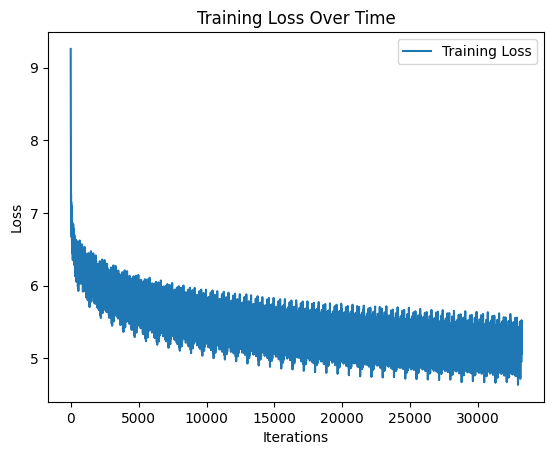

In [14]:
import matplotlib.pyplot as plt

plt.plot(total_loss, label="Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.legend()
plt.show()

### 测试

训练完成后，可以在相同的语言上比较一下这个简单RNN和GPT2的输出，并计算PPL。

仿照你在上面实现的内容，完成针对RNN模型的PPL计算函数。

你的RNN计算的PPL肯定不比GPT2的PPL低，但你可以通过调参或其他办法，在维持较低loss水平的同时降低你的RNN的PPL。

> Bonus: 如果你的PPL显著低于用默认参数训练的baseline，助教在成功复现你的结果之后，将会得到额外加分（仅针对本次作业）。

In [15]:
text1 = "GPT-4 is a large multimodal model (accepting image and text inputs, emitting text outputs) that, while less capable than humans in many real-world scenarios, exhibits human-level performance on various professional and academic benchmarks."
text2 = "Until the rocket ship nearly imploded. On Nov. 17, OpenAI's nonprofit board of directors fired Altman, without warning or even much in the way of explanation. The surreal maneuvering that followed made the corporate dramas of Succession seem staid. Employees revolted. So did OpenAI's powerful investors; one even baselessly speculated that one of the directors who defenestrated Altman was a Chinese spy. The company's visionary chief scientist voted to oust his fellow co-founder, only to backtrack. Two interim CEOs came and went. The players postured via selfie, open letter, and heart emojis on social media. Meanwhile, the company's employees and its board of directors faced off in “a gigantic game of chicken,” says a person familiar with the discussions. At one point, OpenAI's whole staff threatened to quit if the board didn't resign and reinstall Altman within a few hours, three people involved in the standoff tell TIME. Then Altman looked set to decamp to Microsoft—with potentially hundreds of colleagues in tow. It seemed as if the company that catalyzed the AI boom might collapse overnight."

def calculate_rnn_ppl(model, text):
    ppl = None
    ## TODO: 首先将文本转换为输入token (1分)
    words = text.split()
    input_ids = [vocab[w] for w in words if w in vocab]
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(1).to(device)  # (seq_len, batch_size=1)
    
    # 获取模型的输出
    model.eval()
    with torch.no_grad():
        # 这里必须传入 hidden 初始状态
        hidden = model.init_hidden(1).to(device)
        outputs = model(input_ids, hidden)
        logits = outputs.logits
        labels = input_ids.to(logits.device)
        
        # RNN每个位置都是预测下一个token的概率，所以需要将labels向左移动一位
        shift_logits = logits[:-1, ...] # 去掉最后一个预测
        shift_labels = labels[1:, ...]  # 错位一个进行对齐预测

        ## TODO: 根据logits和labels计算model在text上的ppl
        ## Hint: 可以复制粘贴前一个实现的代码
        loss = torch.nn.functional.cross_entropy(shift_logits.view(-1, shift_logits.size(-1)), shift_labels.view(-1))
        ppl = torch.exp(loss)
    return ppl

print(calculate_rnn_ppl(model, text1))
print(calculate_rnn_ppl(model, text2))

tensor(1224.2556, device='cuda:0')
tensor(706.3084, device='cuda:0')


默认：2076.7834， 802.3109